# 07 - Clustering (PuneBite Analyzer)

**Objective:** group Pune restaurants into a few meaningful segments (for example budget, premium, polarising) using unsupervised learning, and check that the segments are not an accident of one algorithm.
**Input:** `data/processed/restaurants_clean.csv`
**Output:** `data/processed/restaurants_clusters.csv` (`url`, `cluster`, `cluster_name`) used by the API and dashboard
**Syllabus link:** Unit VI (K-Means, hierarchical clustering, DBSCAN, Gaussian mixture models, density estimation, histograms).

**Scope:** only restaurants that have a rating **and** at least one vote (a rating of a restaurant nobody reviewed is a placeholder). The dataset has **no latitude/longitude**, so there is no map-based clustering; we cluster on behaviour (rating, popularity, price, polarisation, amenities).

> `polarization_pct` (share of 5-star + 1-star reviews) is built from the star percentages. That is fine here because clustering is descriptive analysis, not a model that predicts the rating. We never feed these clusters back into the rating models.

In [1]:
import os, sys, warnings
sys.path.append(os.path.abspath(".."))
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.mixture import GaussianMixture
from sklearn.decomposition import PCA
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import silhouette_score, adjusted_rand_score

pd.set_option("display.width", 200)
sns.set_theme(style="whitegrid")
RANDOM_STATE = 42

df = pd.read_csv("../data/processed/restaurants_clean.csv")
print("All restaurants:", len(df))
print("Rated, but zero votes (excluded):", int((df["rating"].notna() & (df["votes"] == 0)).sum()))
m = df[df["rating"].notna() & (df["votes"] > 0)].copy()
print("Rated with votes > 0:", len(m))
print("Missing polarization_pct (dropped):", int(m["polarization_pct"].isna().sum()))
m = m.dropna(subset=["polarization_pct"]).reset_index(drop=True)
print("Restaurants to cluster:", len(m))

All restaurants: 12134
Rated, but zero votes (excluded): 17
Rated with votes > 0: 7652
Missing polarization_pct (dropped): 4
Restaurants to cluster: 7648

## 1. Look at the features first (histograms and density estimation)
Votes and price are heavily right-skewed: a few restaurants have thousands of votes, most have a handful. K-Means uses distances, so one huge value would dominate. We use `log1p(votes)` and `log(cost)` to pull the long tail in. The histogram + kernel density (KDE) plots show the effect.

Skewness raw votes: 6.8 -> log: 0.7
Skewness raw cost : 2.0 -> log: 0.2

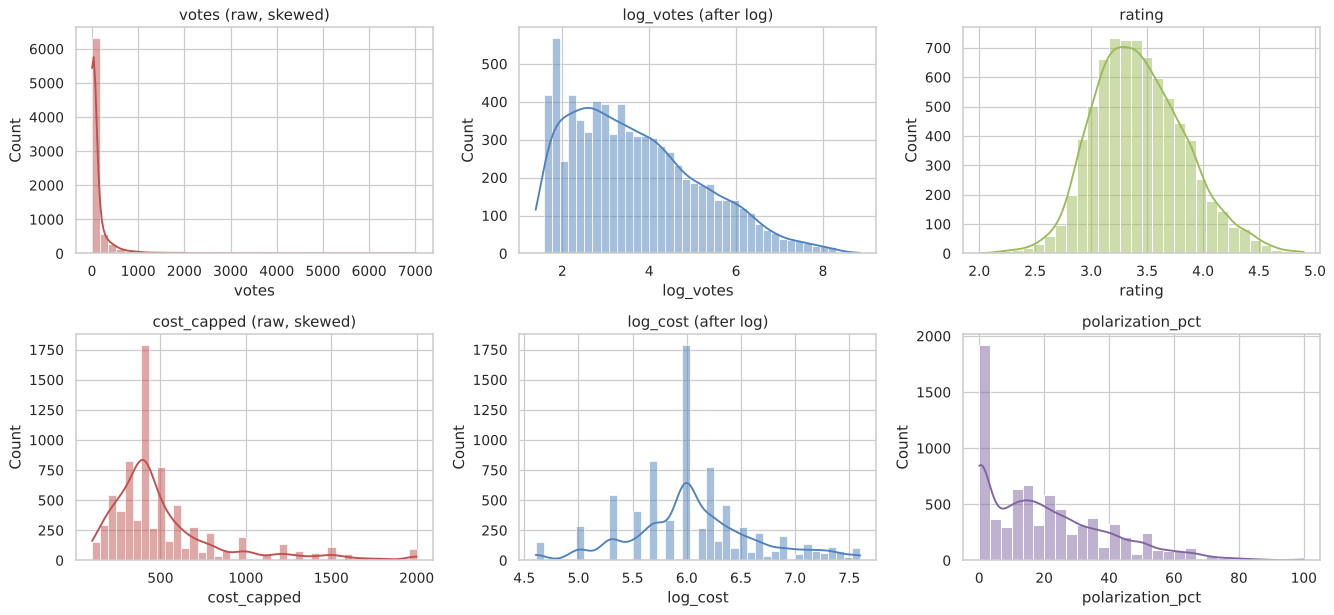

In [2]:
m["log_votes"] = np.log1p(m["votes"])
m["log_cost"] = np.log(m["cost_capped"])

FEATURES = ["rating", "log_votes", "log_cost", "polarization_pct", "n_amenities"]

fig, ax = plt.subplots(2, 3, figsize=(15, 7))
pairs = [("votes", "log_votes"), ("cost_capped", "log_cost")]
for r, (raw, logged) in enumerate(pairs):
    sns.histplot(m[raw], bins=40, kde=True, ax=ax[r, 0], color="#c0504d")
    ax[r, 0].set_title(f"{raw} (raw, skewed)")
    sns.histplot(m[logged], bins=40, kde=True, ax=ax[r, 1], color="#4f81bd")
    ax[r, 1].set_title(f"{logged} (after log)")
sns.histplot(m["rating"], bins=30, kde=True, ax=ax[0, 2], color="#9bbb59"); ax[0, 2].set_title("rating")
sns.histplot(m["polarization_pct"], bins=30, kde=True, ax=ax[1, 2], color="#8064a2"); ax[1, 2].set_title("polarization_pct")
plt.tight_layout()
print("Skewness raw votes: %.1f -> log: %.1f" % (m["votes"].skew(), m["log_votes"].skew()))
print("Skewness raw cost : %.1f -> log: %.1f" % (m["cost_capped"].skew(), m["log_cost"].skew()))

In [3]:
print(m[FEATURES].corr().round(2))
scaler = StandardScaler()
X = scaler.fit_transform(m[FEATURES])
print("Scaled matrix:", X.shape)

                  rating  log_votes  log_cost  polarization_pct  n_amenities
rating              1.00       0.70      0.27             -0.30         0.34
log_votes           0.70       1.00      0.42              0.05         0.44
log_cost            0.27       0.42      1.00              0.01         0.45
polarization_pct   -0.30       0.05      0.01              1.00        -0.02
n_amenities         0.34       0.44      0.45             -0.02         1.00
Scaled matrix: (7648, 5)

## 2. Choose k for K-Means (elbow and silhouette)
* **Elbow:** inertia (within-cluster squared distance) always falls as k grows; we look for where the drop flattens.
* **Silhouette:** how well each point fits its own cluster versus the nearest other one (-1 to 1; higher is better).

 k  inertia  silhouette
 2  26526.0       0.315
 3  20895.0       0.267
 4  17097.0       0.267
 5  15589.0       0.235
 6  14344.0       0.225
 7  13319.0       0.215
 8  12453.0       0.215
 9  11776.0       0.206
10  11163.0       0.207

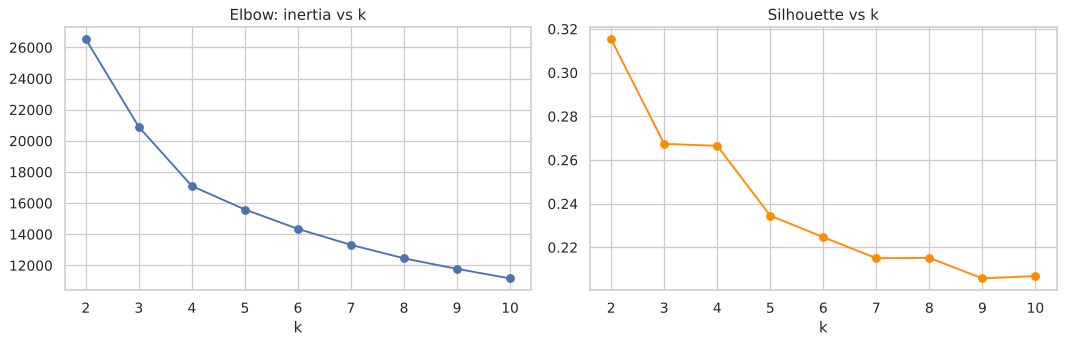

In [4]:
ks = range(2, 11)
inertia, sil = [], []
for k in ks:
    km = KMeans(n_clusters=k, n_init=10, random_state=RANDOM_STATE).fit(X)
    inertia.append(km.inertia_)
    sil.append(silhouette_score(X, km.labels_, sample_size=4000, random_state=RANDOM_STATE))

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(list(ks), inertia, "o-"); ax[0].set_title("Elbow: inertia vs k"); ax[0].set_xlabel("k")
ax[1].plot(list(ks), sil, "o-", color="darkorange"); ax[1].set_title("Silhouette vs k"); ax[1].set_xlabel("k")
plt.tight_layout()
print(pd.DataFrame({"k": list(ks), "inertia": np.round(inertia), "silhouette": np.round(sil, 3)}).to_string(index=False))

**Reading the plots.** Silhouette is highest at k = 2, but that split is trivial (well-liked and busy versus the rest) and tells the business little. Between k = 3 and 6 silhouette is flat and low (about 0.22-0.27), meaning the data forms **overlapping groups, not sharply separated islands**. That is normal for real customer data. The elbow flattens around k = 4-5. We choose **k = 5** because it is the smallest k that separates a distinct budget group from the mainstream group (k = 4 merges them), and it falls in the expected 4-5 range.

In [5]:
K = 5
km = KMeans(n_clusters=K, n_init=20, random_state=RANDOM_STATE).fit(X)
m["cluster"] = km.labels_
print("Silhouette (k=5): %.3f" % silhouette_score(X, km.labels_, sample_size=4000, random_state=RANDOM_STATE))

# stability: do other random starts find the same groups?
aris = []
for seed in (1, 7, 21, 99, 123):
    other = KMeans(n_clusters=K, n_init=10, random_state=seed).fit(X).labels_
    aris.append(adjusted_rand_score(km.labels_, other))
print("Adjusted Rand Index vs 5 other seeds: min %.3f, mean %.3f" % (min(aris), np.mean(aris)))

Silhouette (k=5): 0.235
Adjusted Rand Index vs 5 other seeds: min 0.577, mean 0.911

## 3. Profile the clusters
We describe each cluster in the original units (medians for skewed variables) and look at its typical restaurant types, cuisines and localities.

In [6]:
profile = m.groupby("cluster").agg(
    restaurants=("rating", "size"),
    mean_rating=("rating", "mean"),
    median_votes=("votes", "median"),
    median_cost=("cost_capped", "median"),
    mean_polarization=("polarization_pct", "mean"),
    mean_amenities=("n_amenities", "mean"),
    share_4plus=("rating", lambda s: (s >= 4.0).mean()),
).round(2)
profile

         restaurants  mean_rating  median_votes  median_cost  mean_polarization  mean_amenities  share_4plus
cluster                                                                                                     
0               2054         3.25          11.0        400.0               6.32            2.73         0.00
1                712         4.00         390.5       1300.0              15.16            9.13         0.55
2               2061         3.78         117.0        500.0              19.12            3.63         0.22
3               1705         3.04          20.0        400.0              47.23            3.27         0.00
4               1116         3.39          18.0        200.0              11.32            3.52         0.01

In [7]:
def top_share(series, n=3):
    vc = series.value_counts(normalize=True).head(n)
    return ", ".join(f"{k} {v:.0%}" for k, v in vc.items())

rows = []
for c, g in m.groupby("cluster"):
    cuis = g["cuisines"].str.split("|").explode().value_counts(normalize=True).head(4)
    rows.append({"cluster": c,
                 "top_types": top_share(g["primary_type"]),
                 "top_cuisines": ", ".join(f"{k} {v:.0%}" for k, v in cuis.items()),
                 "top_localities": top_share(g["locality"])})
pd.DataFrame(rows).set_index("cluster")

                                                top_types                                                    top_cuisines                            top_localities
cluster                                                                                                                                                            
0        Quick Bites 42%, Casual Dining 24%, Takeaway 14%  North Indian 26%, Chinese 20%, Fast Food 11%, Maharashtrian 5%         Kothrud 5%, Hadapsar 5%, Wakad 5%
1                   Casual Dining 55%, Bar 21%, Lounge 8%      North Indian 19%, Chinese 12%, Continental 11%, Italian 8%    Baner 9%, Viman Nagar 8%, Hinjawadi 7%
2             Quick Bites 36%, Casual Dining 35%, Café 6%  North Indian 20%, Chinese 15%, Fast Food 11%, Maharashtrian 4%      Viman Nagar 6%, Kothrud 5%, Wakad 5%
3         Quick Bites 46%, Casual Dining 29%, Takeaway 9%        North Indian 26%, Chinese 21%, Fast Food 10%, Biryani 5%  Sinhgad Road 6%, Hadapsar 6%, Kothrud 4%
4           Quic

## 4. Name the clusters
Names are assigned from the measured profile (not guessed) by simple rules, so the notebook gives the same names every time it is re-run:
* highest median cost -> **Premium and popular**
* highest polarisation -> **Polarising**
* lowest median cost -> **Budget everyday**
* of the two left: more votes -> **Solid mainstream**, fewer votes -> **New or unproven**

In [8]:
names = {}
left = set(profile.index)
prem = profile["median_cost"].idxmax();            names[prem] = "Premium and popular"; left.discard(prem)
pol = profile.loc[list(left), "mean_polarization"].idxmax(); names[pol] = "Polarising"; left.discard(pol)
bud = profile.loc[list(left), "median_cost"].idxmin();       names[bud] = "Budget everyday"; left.discard(bud)
main = profile.loc[list(left), "median_votes"].idxmax();     names[main] = "Solid mainstream"; left.discard(main)
names[left.pop()] = "New or unproven"

m["cluster_name"] = m["cluster"].map(names)
summary = profile.assign(name=pd.Series(names)).set_index("name").sort_values("median_votes", ascending=False)
summary

                     restaurants  mean_rating  median_votes  median_cost  mean_polarization  mean_amenities  share_4plus
name                                                                                                                    
Premium and popular          712         4.00         390.5       1300.0              15.16            9.13         0.55
Solid mainstream            2061         3.78         117.0        500.0              19.12            3.63         0.22
Polarising                  1705         3.04          20.0        400.0              47.23            3.27         0.00
Budget everyday             1116         3.39          18.0        200.0              11.32            3.52         0.01
New or unproven             2054         3.25          11.0        400.0               6.32            2.73         0.00

## 5. See the clusters in 2D (PCA)
PCA squeezes the 5 standardised features into 2 axes so we can draw them. The axes are combinations of features, so we also print the loadings.

Variance explained by PC1, PC2: 46.7%, 22.7%
                   PC1   PC2
rating            0.52 -0.36
log_votes         0.56  0.08
log_cost          0.44  0.30
polarization_pct -0.10  0.85
n_amenities       0.46  0.22

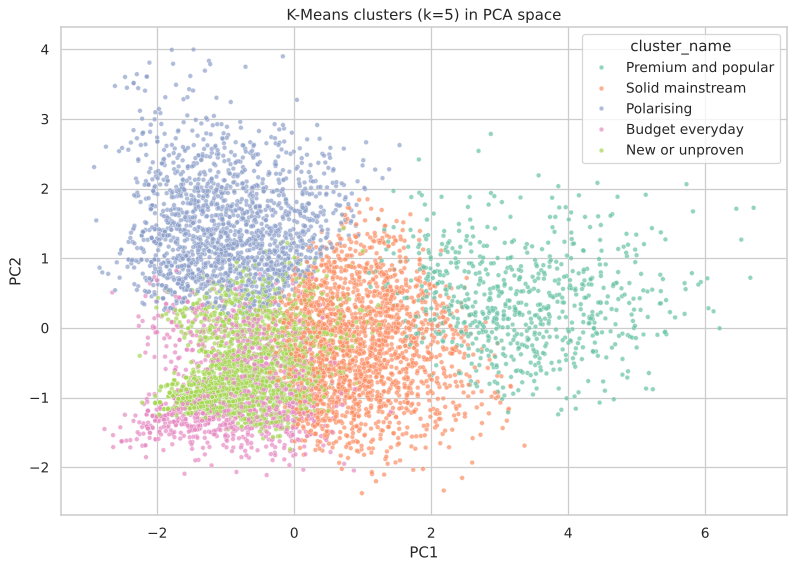

In [9]:
pca = PCA(n_components=2, random_state=RANDOM_STATE)
P = pca.fit_transform(X)
print("Variance explained by PC1, PC2: %.1f%%, %.1f%%" % tuple(100 * pca.explained_variance_ratio_))
print(pd.DataFrame(pca.components_.T, index=FEATURES, columns=["PC1", "PC2"]).round(2))

fig, ax = plt.subplots(figsize=(9, 6.5))
sns.scatterplot(x=P[:, 0], y=P[:, 1], hue=m["cluster_name"], palette="Set2", s=14, alpha=0.7, ax=ax)
ax.set_xlabel("PC1"); ax.set_ylabel("PC2"); ax.set_title("K-Means clusters (k=5) in PCA space")
plt.tight_layout()

## 6. Compare with other methods
If a different algorithm finds similar groups, we can trust the structure more. We compare with:
* **Hierarchical (Ward)** on a random sample of 1,500 (the distance matrix of 7,600 points is too heavy to draw a readable dendrogram),
* **DBSCAN**, which finds dense regions and flags the rest as noise (outliers),
* **Gaussian Mixture Model (GMM)**, which gives soft, elliptical clusters; the number of components is chosen by BIC.

### 6a. Hierarchical clustering (Ward)

Hierarchical cluster sizes: [229 326 229 200 516]
ARI vs K-Means on the same sample: 0.324
Silhouette (hierarchical, sample): 0.154

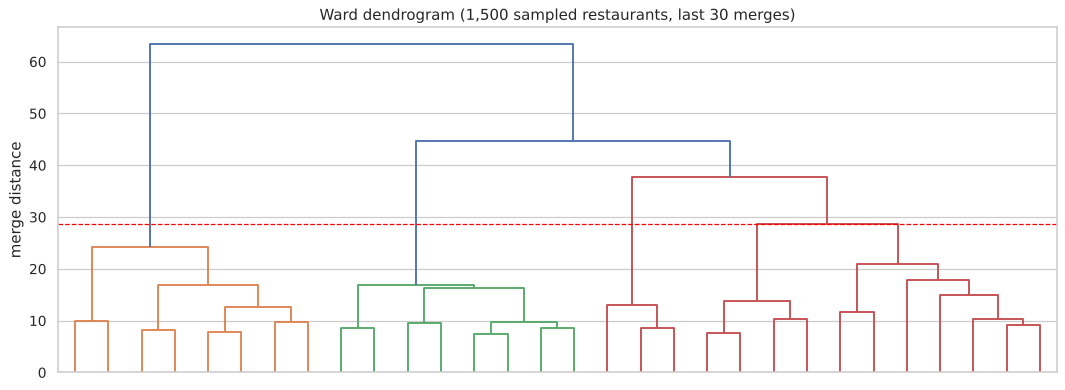

In [10]:
rng = np.random.RandomState(RANDOM_STATE)
idx = rng.choice(len(X), 1500, replace=False)
Xs = X[idx]
Z = linkage(Xs, method="ward")

fig, ax = plt.subplots(figsize=(12, 4.5))
dendrogram(Z, truncate_mode="lastp", p=30, show_leaf_counts=True, no_labels=True, ax=ax)
ax.axhline(Z[-4, 2] - 0.01, color="red", ls="--", lw=1)
ax.set_title("Ward dendrogram (1,500 sampled restaurants, last 30 merges)"); ax.set_ylabel("merge distance")
plt.tight_layout()

hier = fcluster(Z, t=K, criterion="maxclust") - 1
print("Hierarchical cluster sizes:", np.bincount(hier))
print("ARI vs K-Means on the same sample: %.3f" % adjusted_rand_score(m["cluster"].values[idx], hier))
print("Silhouette (hierarchical, sample): %.3f" % silhouette_score(Xs, hier))

### 6b. DBSCAN
`min_samples` = 10 (twice the number of features). To choose `eps` we plot every point's distance to its 10th nearest neighbour, sorted; the bend ("knee") separates dense points from sparse ones. The curve bends between the 80th and 90th percentile (about 0.7-0.8), so we test a range of values and take **eps = 0.7**.

{'p50': 0.51, 'p80': 0.69, 'p90': 0.83, 'p95': 0.96, 'p99': 1.33}

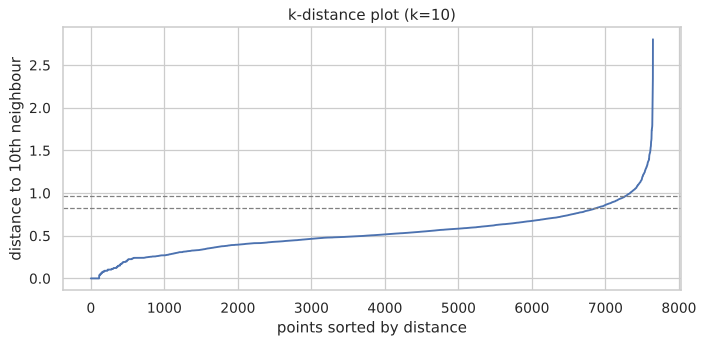

In [11]:
MIN_SAMPLES = 10
nn = NearestNeighbors(n_neighbors=MIN_SAMPLES).fit(X)
kdist = np.sort(nn.kneighbors(X)[0][:, -1])

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(kdist); ax.set_title("k-distance plot (k=10)"); ax.set_xlabel("points sorted by distance"); ax.set_ylabel("distance to 10th neighbour")
for q in (0.90, 0.95):
    ax.axhline(np.quantile(kdist, q), ls="--", lw=1, color="grey")
plt.tight_layout()
print({f"p{int(q*100)}": round(float(np.quantile(kdist, q)), 2) for q in (0.5, 0.8, 0.9, 0.95, 0.99)})

In [12]:
rows = []
for eps in (0.4, 0.5, 0.6, 0.7, 0.8, 1.0):
    lab = DBSCAN(eps=eps, min_samples=MIN_SAMPLES).fit_predict(X)
    rows.append({"eps": eps, "clusters": len(set(lab)) - (1 if -1 in lab else 0), "noise_points": int((lab == -1).sum()),
                 "noise_pct": round(100 * (lab == -1).mean(), 1)})
pd.DataFrame(rows)

   eps  clusters  noise_points  noise_pct
0  0.4        28          4746       62.1
1  0.5        11          2707       35.4
2  0.6         7          1291       16.9
3  0.7         1           617        8.1
4  0.8         1           302        3.9
5  1.0         1            98        1.3

In [13]:
EPS = 0.7
db = DBSCAN(eps=EPS, min_samples=MIN_SAMPLES).fit(X)
m["dbscan"] = db.labels_
n_clu = len(set(db.labels_)) - (1 if -1 in db.labels_ else 0)
print(f"eps={EPS}: {n_clu} clusters, {int((db.labels_ == -1).sum())} noise points ({100 * (db.labels_ == -1).mean():.1f}%)")
print("DBSCAN cluster sizes (-1 = noise):", dict(pd.Series(db.labels_).value_counts().sort_index()))
print()
print("What do the noise points (outliers) look like vs everyone else?")
m.assign(is_noise=m["dbscan"] == -1).groupby("is_noise")[["rating", "votes", "cost_capped", "polarization_pct", "n_amenities"]].median().round(1)

eps=0.7: 1 clusters, 617 noise points (8.1%)
DBSCAN cluster sizes (-1 = noise): {-1: np.int64(617), 0: np.int64(7031)}

What do the noise points (outliers) look like vs everyone else?

          rating  votes  cost_capped  polarization_pct  n_amenities
is_noise                                                           
False        3.4   28.0        400.0              16.0          3.0
True         3.5  106.0        650.0              26.0          6.0

### 6c. Gaussian Mixture Model (choose components by BIC)

BIC-best number of components: 10
GMM (5 components) sizes: [2139 1742  875 1804 1088]
ARI K-Means vs GMM(5): 0.394

Share of each K-Means cluster that falls into each GMM component (rows sum to 100%):

gmm                     0     1     2     3     4
cluster_name                                     
Budget everyday      0.08  0.50  0.00  0.41  0.01
New or unproven      0.03  0.30  0.01  0.62  0.04
Polarising           0.21  0.21  0.00  0.00  0.58
Premium and popular  0.03  0.00  0.96  0.00  0.00
Solid mainstream     0.77  0.11  0.08  0.03  0.00

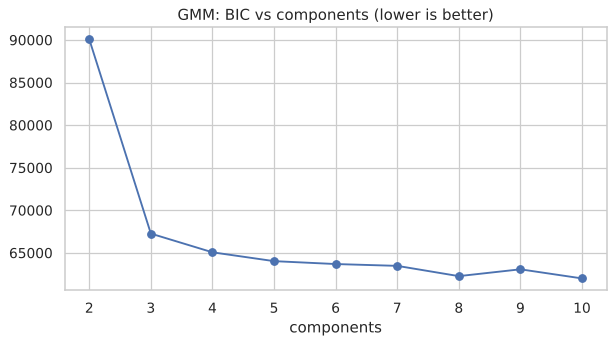

In [14]:
bics = []
for k in range(2, 11):
    g = GaussianMixture(n_components=k, covariance_type="full", n_init=3, random_state=RANDOM_STATE).fit(X)
    bics.append(g.bic(X))
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(range(2, 11), bics, "o-"); ax.set_title("GMM: BIC vs components (lower is better)"); ax.set_xlabel("components")
plt.tight_layout()
best_k = int(np.argmin(bics)) + 2
print("BIC-best number of components:", best_k)

gmm5 = GaussianMixture(n_components=K, covariance_type="full", n_init=3, random_state=RANDOM_STATE).fit(X)
m["gmm"] = gmm5.predict(X)
print("GMM (5 components) sizes:", np.bincount(m["gmm"]))
print("ARI K-Means vs GMM(5): %.3f" % adjusted_rand_score(m["cluster"], m["gmm"]))
print()
print("Share of each K-Means cluster that falls into each GMM component (rows sum to 100%):")
pd.crosstab(m["cluster_name"], m["gmm"], normalize="index").round(2)

In [15]:
comp = pd.DataFrame({
    "method": ["K-Means (k=5)", "Hierarchical Ward (k=5, sample)", "GMM (5 components)", "DBSCAN (eps=0.7)"],
    "clusters": [K, K, K, n_clu],
    "silhouette": [silhouette_score(X, m["cluster"], sample_size=4000, random_state=RANDOM_STATE),
                   silhouette_score(Xs, hier),
                   silhouette_score(X, m["gmm"], sample_size=4000, random_state=RANDOM_STATE),
                   silhouette_score(X[db.labels_ != -1], db.labels_[db.labels_ != -1], sample_size=4000, random_state=RANDOM_STATE) if n_clu > 1 else np.nan],
    "agreement_with_kmeans_ARI": [1.0,
                                  adjusted_rand_score(m["cluster"].values[idx], hier),
                                  adjusted_rand_score(m["cluster"], m["gmm"]),
                                  adjusted_rand_score(m["cluster"][db.labels_ != -1], db.labels_[db.labels_ != -1])],
}).round(3)
comp

                            method  clusters  silhouette  agreement_with_kmeans_ARI
0                    K-Means (k=5)         5       0.235                      1.000
1  Hierarchical Ward (k=5, sample)         5       0.154                      0.324
2               GMM (5 components)         5       0.155                      0.394
3                 DBSCAN (eps=0.7)         1         NaN                      0.000

## 7. Save the cluster labels
The API and dashboard read this file. Only clustered restaurants (rated, at least one vote) appear; other restaurants simply have no cluster.

In [16]:
out = m[["url", "cluster", "cluster_name"]].copy()
out.to_csv("../data/processed/restaurants_clusters.csv", index=False)
print("Saved", len(out), "rows")
out["cluster_name"].value_counts()

Saved 7648 rows

cluster_name
Solid mainstream       2061
New or unproven        2054
Polarising             1705
Budget everyday        1116
Premium and popular     712
Name: count, dtype: int64

## 8. Summary and findings
* **Data:** 7,648 restaurants (rated, at least one vote, polarisation known). 17 rated restaurants with zero votes and 4 with unknown polarisation were left out.
* **Choosing k:** silhouette is highest at k = 2 (0.315) but that split is too coarse to be useful; for k = 3-6 it is 0.22-0.27. Elbow flattens near 4-5. We used **k = 5** (silhouette 0.235): it separates a cheap group that k = 4 hides inside the mainstream group.
* **The five segments (K-Means):**
  1. **Premium and popular** (712): rating 4.00, median 390 votes, median Rs 1,300 for two, about 9 amenities, 55% rated 4.0+. Mostly Casual Dining, Bars and Lounges (Baner, Viman Nagar, Hinjawadi).
  2. **Solid mainstream** (2,061): rating 3.78, median 117 votes, Rs 500; 22% rated 4.0+.
  3. **Polarising** (1,705): rating 3.04, polarisation 47% (vs 6-19% elsewhere) with few votes: reviewers either love or hate these places.
  4. **Budget everyday** (1,116): median Rs 200, mostly Quick Bites, Street Food and Fast Food, desserts and bakeries; rating 3.39.
  5. **New or unproven** (2,054): median 11 votes, almost no polarisation, rating 3.25: too few reviews to judge.
* **No "hidden gem" cluster appeared.** Highly rated restaurants with few votes are too rare to form their own group (only 0.0-1% of the cheap/low-vote clusters are 4.0+). Hidden gems are therefore found in Phase 8 with a trust-adjusted score instead.
* **How trustworthy are the clusters?** Honestly, moderately. Clusters overlap (silhouette 0.235, not above 0.5). Re-running K-Means with other random seeds gave very similar groups on average (ARI 0.91) but one seed was noticeably different (min 0.58). Other methods agree only partly: Ward hierarchical ARI 0.32 and GMM ARI 0.39 against K-Means. GMM's BIC keeps improving up to 10 components, which says the data is a continuum rather than a few Gaussian blobs. DBSCAN finds one large dense region plus about 8% noise points; the noise points are the bigger, pricier, amenity-rich places (median 106 votes, Rs 650, 6 amenities), i.e. outliers at the premium end, not errors. The **Premium and popular** group is the most distinct and reliable (96% of it lands in a single GMM component); the borders between the middle groups are soft.
* **Limitations:** no location data, so no geographic clusters; `polarization_pct` comes from the star percentages, so these clusters describe restaurants but must not be used as inputs to the rating models (leakage).
* **Output:** `data/processed/restaurants_clusters.csv` (`url`, `cluster`, `cluster_name`) for the API and dashboard.